### Importing the libraries

In [611]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler, RobustScaler, MaxAbsScaler, StandardScaler, FunctionTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import PowerTransformer
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from scipy.stats import boxcox

### Load data from CSV file

In [612]:
restaurants_df = pd.read_csv("../Foursquare/final_restaurants_dataset_cleaned.csv")
coffeeshops_df = pd.read_csv("../Foursquare/final_coffeeshops_dataset_cleaned.csv")
print(restaurants_df.info())
print(coffeeshops_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1221 entries, 0 to 1220
Data columns (total 39 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1221 non-null   object 
 1   Name                                      1221 non-null   object 
 2   Latitude                                  1221 non-null   float64
 3   Longitude                                 1221 non-null   float64
 4   Category                                  1221 non-null   object 
 5   Rating                                    1221 non-null   object 
 6   Popularity                                1221 non-null   float64
 7   Google Place ID                           1221 non-null   object 
 8   Business Status                           1221 non-null   object 
 9   Distance (m)                              1221 non-null   float64
 10  Cluster                             

### Combine and convert generalCategory to numerical

In [613]:
combined_df = pd.concat([coffeeshops_df, restaurants_df], ignore_index=True)
combined_df["generalCategory"] = combined_df["generalCategory"].map({"coffee shop": 0, "restaurant": 1})

# Pre-processing

### Correlation Function 

In [614]:
# Function to remove highly correlated features
def remove_highly_correlated_features(X, threshold=0.9):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

results = []

### info and null values

In [615]:
combined_df.info()
print(combined_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1910 entries, 0 to 1909
Data columns (total 39 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1910 non-null   object 
 1   Name                                      1910 non-null   object 
 2   Latitude                                  1910 non-null   float64
 3   Longitude                                 1910 non-null   float64
 4   Category                                  1910 non-null   object 
 5   Rating                                    1910 non-null   object 
 6   Popularity                                1910 non-null   float64
 7   Google Place ID                           1909 non-null   object 
 8   Business Status                           1910 non-null   object 
 9   Distance (m)                              1910 non-null   float64
 10  Cluster                             

### Filling missing values with the median

In [616]:
combined_df["Avg Rating - Business Type"] = combined_df["Avg Rating - Business Type"].fillna(combined_df["Avg Rating - Business Type"].median())
combined_df["Avg Rating - Food & Dining"] = combined_df["Avg Rating - Food & Dining"].fillna(combined_df["Avg Rating - Food & Dining"].median())

### Drop irrelevent columns

In [617]:
irrelevant_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/POI Density', 'Competition - Business Type/related POIs'
               , 'Competition - Food & Dining/POI Density','Business Name' ,'Google Rating', 'Popularity']
combined_df.drop(columns=irrelevant_columns, inplace=True)

# SVR

In [618]:
# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
combined_df['Number of Reviewers'] = pd.to_numeric(combined_df['Number of Reviewers'], errors='coerce')

# Drop rows where 'Number of Reviewers' is NaN (if you want to ignore them in analysis)
combined_df = combined_df.dropna(subset=['Number of Reviewers'])


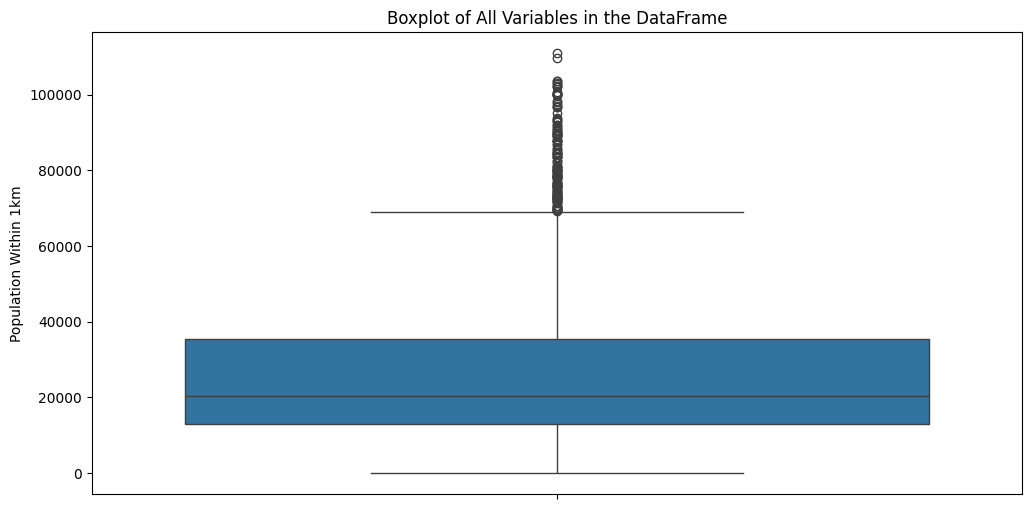

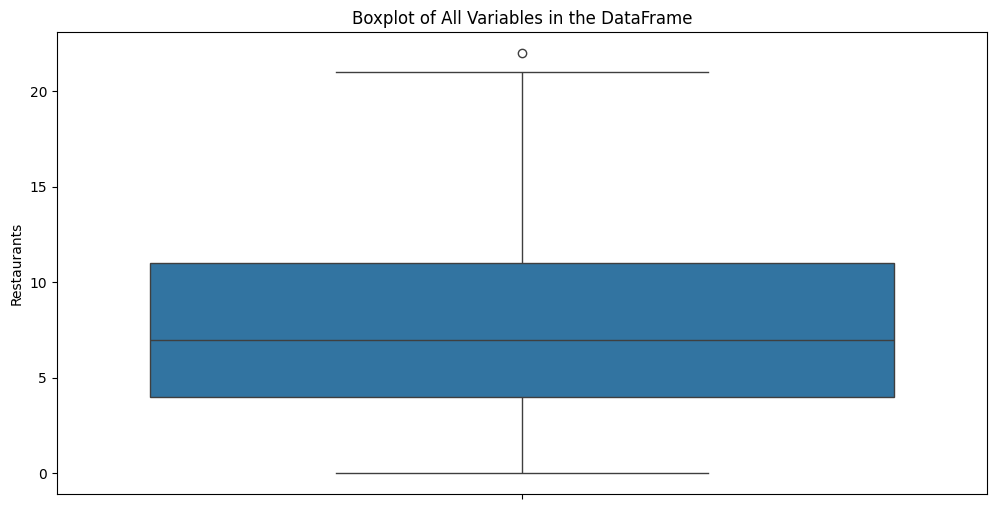

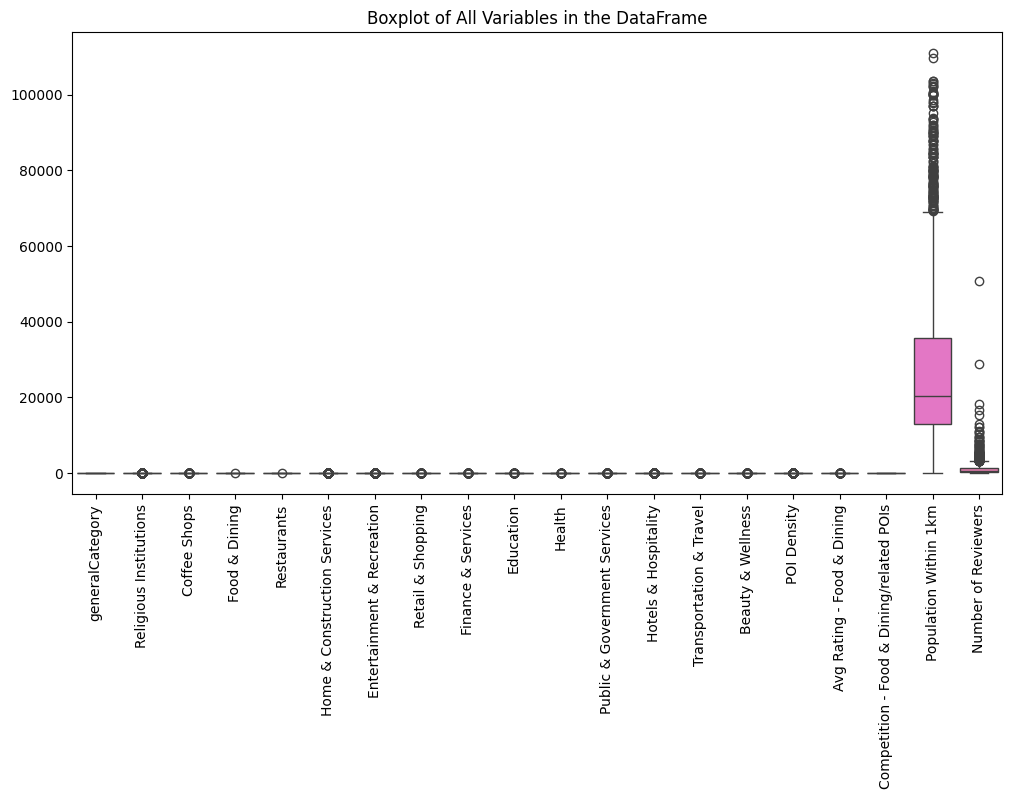

In [619]:
# Assuming you have your dataframe named `df`
def plot_boxplot(df):
    plt.figure(figsize=(12, 6))  # Set the figure size
    sns.boxplot(data=df)  # Create a boxplot for all variables in the dataframe
    plt.xticks(rotation=90)  # Rotate the x-axis labels for better readability
    plt.title("Boxplot of All Variables in the DataFrame")  # Set the title
    plt.show()

plot_boxplot(combined_df['Population Within 1km'])
plot_boxplot(combined_df['Restaurants'])
plot_boxplot(combined_df)

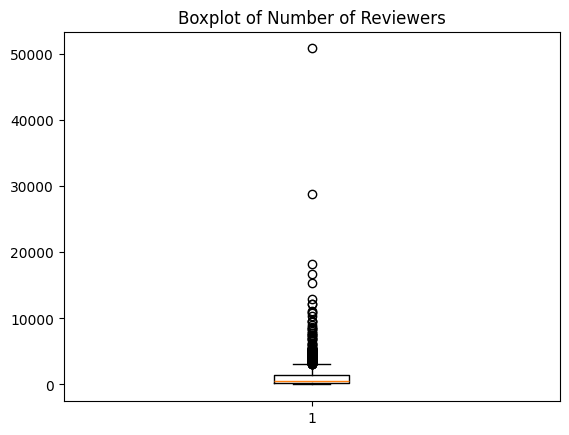

In [620]:
plt.boxplot(combined_df["Number of Reviewers"])
plt.title("Boxplot of Number of Reviewers")
plt.show()


In [621]:
variance = combined_df["Number of Reviewers"].var()
# Print result
print(f"Variance of Number of Reviewers: {variance}")

Variance of Number of Reviewers: 4263982.591482897


In [622]:
combined_df.skew()

generalCategory                             -0.581800
Religious Institutions                       2.087645
Coffee Shops                                 1.843367
Food & Dining                                0.368945
Restaurants                                  0.433631
Home & Construction Services                 2.138622
Entertainment & Recreation                   3.900224
Retail & Shopping                            1.177599
Finance & Services                           0.569625
Education                                    1.921357
Health                                       1.334315
Public & Government Services                 1.472330
Hotels & Hospitality                         3.324097
Transportation & Travel                      3.532612
Beauty & Wellness                            1.565588
POI Density                                -11.039143
Avg Rating - Food & Dining                  -2.910302
Competition - Food & Dining/related POIs    -0.060451
Population Within 1km       

In [623]:
transformed_df = combined_df.copy()

# Remove outliers in 'Number of Reviewers' using IQR method
Q1 = transformed_df['Number of Reviewers'].quantile(0.25)
Q3 = transformed_df['Number of Reviewers'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
transformed_df = transformed_df[(transformed_df['Number of Reviewers'] >= lower_bound) & (transformed_df['Number of Reviewers'] <= upper_bound)]

# Remove outliers in 'Population Within 1km' using IQR method
Q1 = transformed_df['Population Within 1km'].quantile(0.25)
Q3 = transformed_df['Population Within 1km'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
transformed_df = transformed_df[(transformed_df['Population Within 1km'] >= lower_bound) & (transformed_df['Population Within 1km'] <= upper_bound)]

# Remove outliers in 'Restaurants' using IQR method
Q1 = transformed_df['Restaurants'].quantile(0.25)
Q3 = transformed_df['Restaurants'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
transformed_df = transformed_df[(transformed_df['Restaurants'] >= lower_bound) & (transformed_df['Restaurants'] <= upper_bound)]


num_cols = transformed_df.select_dtypes(include=['number']).columns
# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

In [624]:
# num_cols = transformed_df.select_dtypes(include=['number']).columns

# def transform_skewed_features(df, skew_threshold=1):
#     transformed_df = df.copy()
    
#     for col in df.select_dtypes(include=[np.number]).columns:  # Only apply to numerical columns
#         skewness = df[col].skew()

#         if skewness < -skew_threshold:  # Highly left-skewed
#             print(f"Applying square transformation to {col}")
#             transformed_df[col] = df[col] ** 2
        
#         elif skewness > skew_threshold:  # Highly right-skewed
#             if (df[col] > 0).all():  # Box-Cox requires positive values
#                 print(f"Applying Box-Cox transformation to {col}")
#                 transformed_df[col], _ = boxcox(df[col])  # Box-Cox transformation
#             else:
#                 print(f"Applying log transformation to {col}")
#                 transformed_df[col] = np.log1p(df[col])  # Log transformation
            
#         else:
#             print(f"No transformation applied to {col} (skew: {skewness:.3f})")
    
#     return transformed_df

# transformed_df = transform_skewed_features(transformed_df)

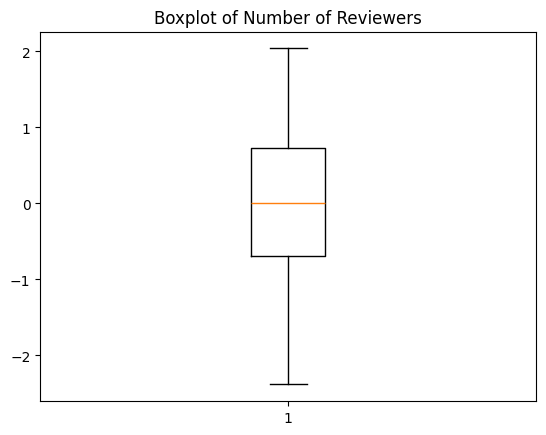

In [625]:
plt.boxplot(transformed_df["Number of Reviewers"])
plt.title("Boxplot of Number of Reviewers")
plt.show()

### MinMax Scaling 

In [626]:
# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

## SVR MODEL EXP 1  (Target = Number of Revieweres)

In [627]:
# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Number of Reviewers'])
y = transformed_df['Number of Reviewers']

# Apply function and capture removed features for correlation
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.8)
print(f"Removed highly correlated features: {removed_corr_features}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")

# Check for constant features in X_train
constant_features = [col for col in X_train.columns if X_train[col].nunique() == 1]

# Drop constant features
X_train = X_train.drop(columns=constant_features)
X_test = X_test.drop(columns=constant_features)

# Print out constant features that were removed
print(f"Removed constant features: {constant_features}")


# Check for NaNs or infinite values in the data
check_nan_inf(X_train, y_train)

# Set up the pipeline
model = Pipeline([
    ('svr', SVR())  # Apply SVR without additional transformation on the target
])

# Define parameter grid for tuning SVR
param_grid = {
    'svr__C': [0.01, 0.1, 1, 10],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__kernel': ['rbf', 'sigmoid']
}

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the model with training data
grid_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Removed highly correlated features: ['Restaurants']
Removed constant features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__C': 0.1, 'svr__epsilon': 0.01, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}
Best score (MSE):  -0.09802484209132148
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.2109
MSE             │     0.0445
MAE             │     0.1720
R²              │     0.1505
MedAE           │     0.1510
Max Error       │     0.5160
MAD             │     0.1884
Model evaluation completed!


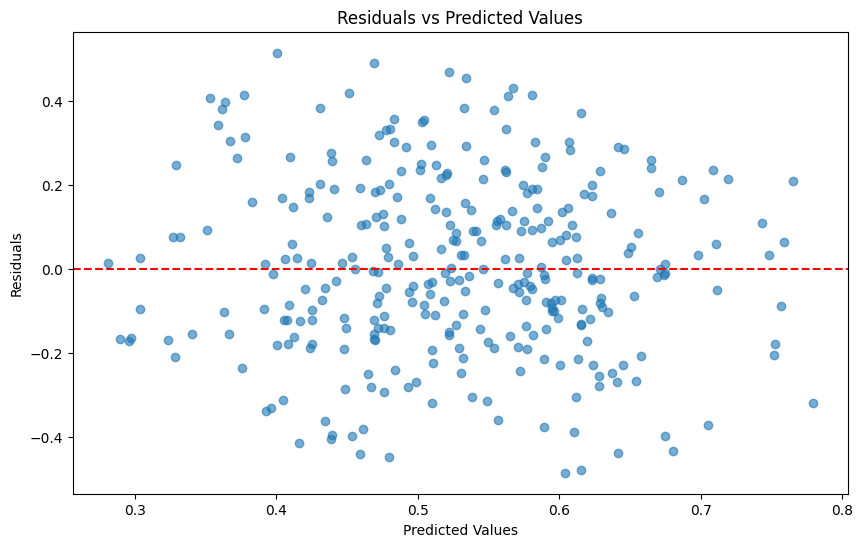

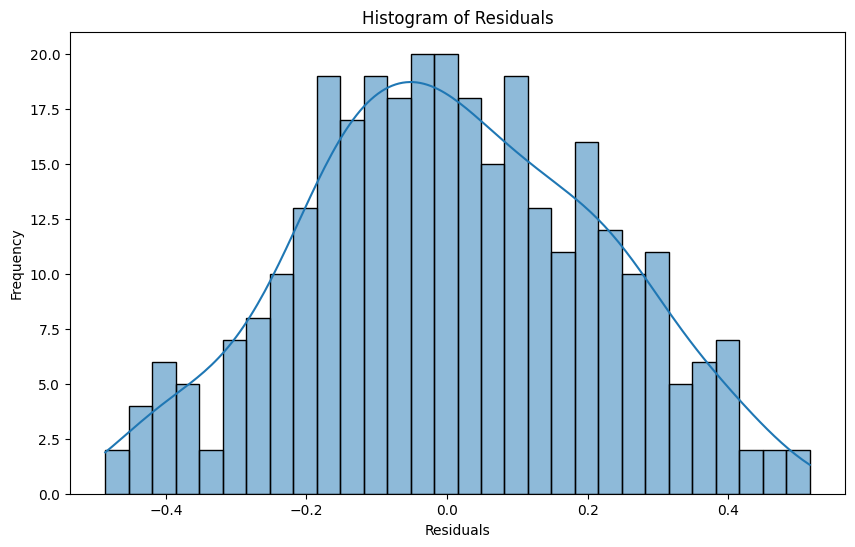

In [628]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have your actual values (y_test_actual) and predicted values (y_pred_original)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

# Plot a histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


In [629]:
variance = transformed_df["Number of Reviewers"].var()
# Print result
print(f"Variance of Number of Reviewers: {variance}")

Variance of Number of Reviewers: 0.051211251715969554


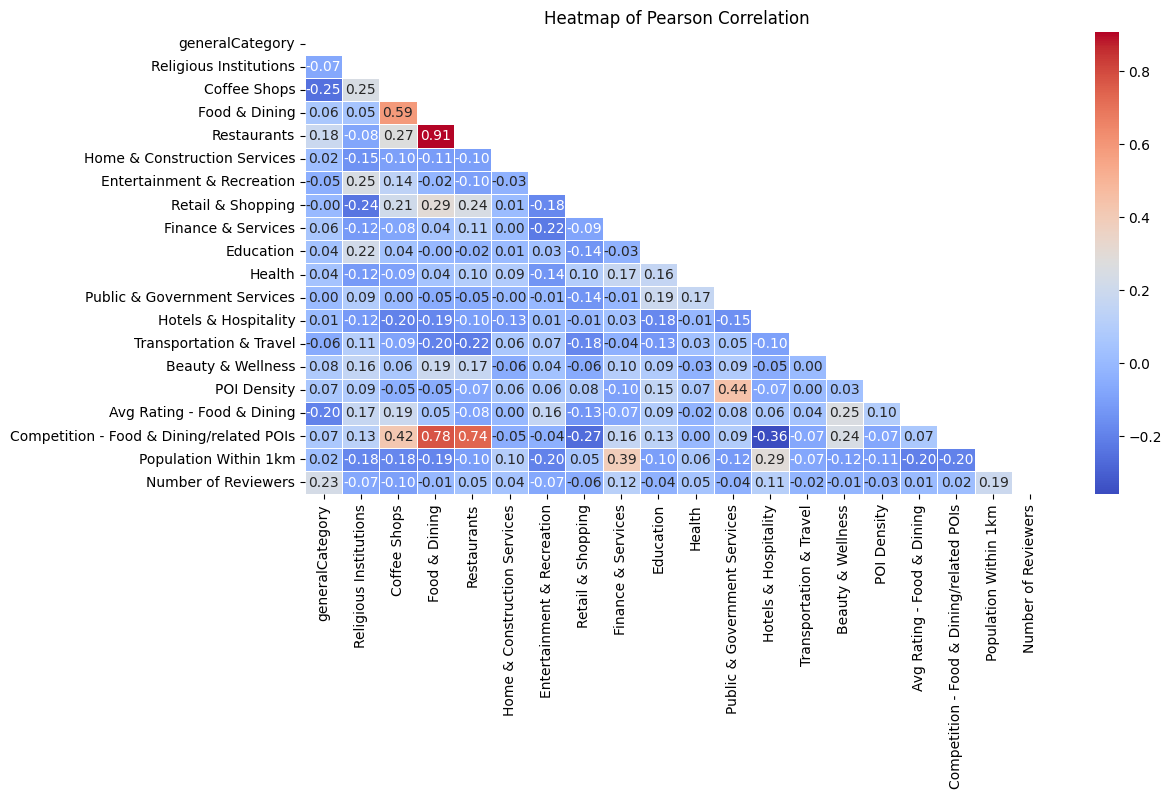

In [630]:
# Compute Pearson correlation for scaled data
corr_matrix = transformed_df.corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()

In [631]:
results_df = X_test.copy()  # Use test set features
results_df["Actual_Y"] = y_test
results_df["Predicted_Y"] = y_pred

In [632]:
# Print the DataFrame
results_df

,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,Education,Health,Public & Government Services,Hotels & Hospitality,Transportation & Travel,Beauty & Wellness,POI Density,Avg Rating - Food & Dining,Competition - Food & Dining/related POIs,Population Within 1km,Actual_Y,Predicted_Y
1103,1.0,0.000000,0.356356,0.626451,0.000000,0.81549,0.490265,0.541994,0.000000,0.284412,0.000000,0.824054,0.223283,0.645508,0.510174,0.570236,0.531771,0.558997,0.796428,0.623259
1332,1.0,0.000000,0.452883,0.430505,0.000000,0.00000,0.513836,0.184632,0.572473,0.965891,0.854863,0.000000,0.223283,0.000000,0.510174,0.453297,0.512902,0.587351,0.676848,0.508592
1543,1.0,0.000000,0.000000,0.656291,0.994705,0.00000,0.671987,0.324023,0.311870,0.653849,0.548738,0.000000,0.594014,0.565596,0.510174,0.537341,0.552737,0.000000,0.547245,0.546286
401,0.0,0.000000,0.356356,0.823645,0.000000,0.81549,0.536359,0.541994,0.000000,0.564559,0.000000,0.770163,0.223283,0.708721,0.361277,0.596177,0.658971,0.854820,0.389647,0.471036
1777,1.0,0.581705,0.452883,0.714141,0.000000,0.00000,0.513836,0.716943,0.311870,0.448801,0.748994,0.366200,0.223283,0.000000,0.716270,0.486801,0.720466,0.816682,0.855524,0.670886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574,1.0,0.000000,0.356356,0.499610,0.994705,0.00000,0.836684,0.440320,0.000000,0.448801,0.548738,0.366200,0.223283,0.000000,0.716270,0.443162,0.317890,0.587690,0.521713,0.567497
851,1.0,0.000000,0.356356,0.430505,0.000000,0.00000,0.411821,0.184632,0.000000,0.284412,0.548738,0.526617,0.347751,0.000000,0.510174,0.489414,0.562823,0.851512,0.460152,0.779189
1898,1.0,0.770573,0.356356,0.499610,0.000000,0.00000,0.536359,0.324023,0.572473,0.284412,0.000000,0.000000,0.223283,0.804798,0.361277,0.485141,0.555452,0.482394,0.510570,0.590563
389,0.0,0.000000,0.528698,0.430505,0.000000,0.00000,0.887416,0.440320,0.646888,0.448801,0.548738,0.000000,0.000000,0.000000,0.716270,0.305207,0.253737,0.466960,0.329081,0.303160


## SVR MODEL EXP 2

In [633]:
# Define features (X) and target variable (y)
X = transformed_df[['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']]
y = transformed_df['Number of Reviewers']


print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.1, 'svr__regressor__gamma': 'scale', 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  -0.03761959524103853
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.2202
MSE             │     0.0485
MAE             │     0.1790
R²              │     0.0738
MedAE           │     0.1580
Max Error       │     0.5800
MAD             │     0.1884
Model evaluation completed!


In [634]:
results_df = X_test.copy()  # Use test set features
results_df["Actual_Y"] = y_test
results_df["Predicted_Y"] = y_pred

In [635]:
results_df

,POI Density,Avg Rating - Food & Dining,Competition - Food & Dining/related POIs,Population Within 1km,Actual_Y,Predicted_Y
1103,0.510174,0.570236,0.531771,0.558997,0.796428,0.552546
1332,0.510174,0.453297,0.512902,0.587351,0.676848,0.553131
1543,0.510174,0.537341,0.552737,0.000000,0.547245,0.498515
401,0.361277,0.596177,0.658971,0.854820,0.389647,0.509523
1777,0.716270,0.486801,0.720466,0.816682,0.855524,0.558420
...,...,...,...,...,...,...
1574,0.716270,0.443162,0.317890,0.587690,0.521713,0.484087
851,0.510174,0.489414,0.562823,0.851512,0.460152,0.582960
1898,0.361277,0.485141,0.555452,0.482394,0.510570,0.547265
389,0.716270,0.305207,0.253737,0.466960,0.329081,0.412458


## Using StandardScaler (Standarization)

In [636]:
# Apply StandardScaling 
stnadard_scaler = StandardScaler()
transformed_df[num_cols] = stnadard_scaler.fit_transform(transformed_df[num_cols])


### EXP 1

In [637]:
# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Popularity'])
y = transformed_df['Popularity']

print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


KeyError: "['Popularity'] not found in axis"

### EXP 2

In [ ]:
# Define features (X) and target variable (y)
X = transformed_df[['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']]
y = transformed_df['Popularity']


print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.01, 'svr__regressor__gamma': 'scale', 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  0.012128037721054285
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     1.0027
MSE             │     1.0054
MAE             │     0.8340
R²              │    -0.0423
MedAE           │     0.7741
Max Error       │     2.3895
MAD             │     0.8301
Model evaluation completed!


## Using RobustScaler

In [ ]:
# Apply RobustScaling 
robust_scaler = RobustScaler()
transformed_df[num_cols] = robust_scaler.fit_transform(transformed_df[num_cols])

### EXP 1

In [ ]:
# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Popularity'])
y = transformed_df['Popularity']

print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['generalCategory', 'Religious Institutions', 'Coffee Shops',
       'Food & Dining', 'Restaurants', 'Home & Construction Services',
       'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services',
       'Education', 'Health', 'Public & Government Services',
       'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness',
       'POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: ['Restaurants']
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.001, 'svr__regressor__gamma': 2, 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  -0.008685551904962762
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.5743
MSE             │     0.3298
MAE     

### EXP 2

In [ ]:
# Define features (X) and target variable (y)
X = transformed_df[['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']]
y = transformed_df['Popularity']


print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.01, 'svr__regressor__gamma': 'scale', 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  0.012185462080297782
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.5961
MSE             │     0.3554
MAE             │     0.4958
R²              │    -0.0424
MedAE           │     0.4603
Max Error       │     1.4203
MAD             │     0.4935
Model evaluation completed!


## Using MaxAbs

In [ ]:
# Apply RobustScaling 
maxAbs_scaler = MaxAbsScaler()
transformed_df[num_cols] = maxAbs_scaler.fit_transform(transformed_df[num_cols])

### EXP 1

In [ ]:
# Define features (X) and target variable (y)
X = transformed_df.drop(columns=['Popularity'])
y = transformed_df['Popularity']

print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['generalCategory', 'Religious Institutions', 'Coffee Shops',
       'Food & Dining', 'Restaurants', 'Home & Construction Services',
       'Entertainment & Recreation', 'Retail & Shopping', 'Finance & Services',
       'Education', 'Health', 'Public & Government Services',
       'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness',
       'POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: ['Restaurants']
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.001, 'svr__regressor__gamma': 2, 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  -0.008695432416225234
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.4927
MSE             │     0.2427
MAE     

### EXP 2

In [ ]:
# Define features (X) and target variable (y)
X = transformed_df[['POI Density', 'Avg Rating - Food & Dining', 'Competition - Food & Dining/related POIs', 'Population Within 1km']]
y = transformed_df['Popularity']


print(X.columns)
# Apply function and capture removed features
X, removed_corr_features = remove_highly_correlated_features(X, threshold=0.9)
print(f"Removed highly correlated features: {removed_corr_features}")
    
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid for tuning
param_grid = {
    'svr__regressor__C': [0.01, 0.1, 1, 10],
    'svr__regressor__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
    'svr__regressor__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__regressor__kernel': ['rbf', 'sigmoid']
}

# Check for NaNs, infinite values, or constant features
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected in the data. Please handle missing values.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected in the data. Check transformations and scaling.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected. Consider dropping them.")


# Set up the pipeline
model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('svr', TransformedTargetRegressor(
        regressor=SVR(),
        transformer=PowerTransformer()
    ))
])

# Replace negative or zero values to avoid PowerTransformer issues
X[X <= 0] = 1e-6

# Check for NaNs or Infs before splitting
check_nan_inf(X, y)

grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='r2')

grid_search.fit(X_train, y_train)

# Check for NaNs in grid search results
if np.isnan(grid_search.cv_results_['mean_test_score']).any():
    print("Warning: NaN values found in GridSearchCV results. Check your data and parameter grid.")

# Print best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score (MSE): ", -grid_search.best_score_)

# Test set predictions using the best estimator
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Predictions on test data completed with the best model.")

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_pred)
max_err = max_error(y_test, y_pred)
mad = np.mean(np.abs(y_test - np.mean(y_test)))

# Print results in table format
print(f"{'Metric':<15} │ {'Value':>10}")
print("-" * 35)
print(f"{'RMSE':<15} │ {rmse:>10.4f}")
print(f"{'MSE':<15} │ {mse:>10.4f}")
print(f"{'MAE':<15} │ {mae:>10.4f}")
print(f"{'R²':<15} │ {r2:>10.4f}")
print(f"{'MedAE':<15} │ {medae:>10.4f}")
print(f"{'Max Error':<15} │ {max_err:>10.4f}")
print(f"{'MAD':<15} │ {mad:>10.4f}")

print("Model evaluation completed!")


Index(['POI Density', 'Avg Rating - Food & Dining',
       'Competition - Food & Dining/related POIs', 'Population Within 1km'],
      dtype='object')
Removed highly correlated features: []
Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best parameters found:  {'svr__regressor__C': 0.1, 'svr__regressor__epsilon': 0.01, 'svr__regressor__gamma': 'scale', 'svr__regressor__kernel': 'rbf'}
Best score (MSE):  0.012198399762330659
Predictions on test data completed with the best model.
Metric          │      Value
-----------------------------------
RMSE            │     0.5115
MSE             │     0.2616
MAE             │     0.4254
R²              │    -0.0425
MedAE           │     0.3949
Max Error       │     1.2196
MAD             │     0.4234
Model evaluation completed!


## Using LogScaling